# LendLogic: Loan Status Prediction using Naïve Bayes
# Objective: To automate the loan approval process by predicting whether a loan application will be approved or rejected based on applicant profiles (Income, Credit History, Education, etc.).
# Techniques: Data Cleaning, Categorical Encoding (Label/One-Hot), Feature Scaling, Naïve Bayes Classification.

# # Part-1: Data Exploration and Pre-processing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML_Projects\ML_Project_5.txt")
data

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,NaN,NaN,NaN,NaN,689.0,NaN,NaN,NaN,NaN,Default
1,2,12.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,NaN,1.0,1.0,1.0,NaN,2.0,Default
2,3,9.0,34,29239.0,1427.0,13559.0,14331.0,14948.0,15549.0,1518.0,15.0,1.0,1.0,1.0,5.0,Not Default
3,4,5.0,37,4699.0,48233.0,49291.0,28314.0,28959.0,29547.0,2.0,219.0,12.0,11.0,169.0,1.0,Not Default
4,5,5.0,57,8617.0,567.0,35835.0,294.0,19146.0,19131.0,2.0,36681.0,1.0,9.0,689.0,679.0,Not Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.0,31237.0,1598.0,85.0,2.0,53.0,347.0,5.0,1.0,Not Default
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.0,519.0,NaN,1837.0,3526.0,8998.0,129.0,NaN,NaN,Not Default
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.0,2582.0,19357.0,NaN,NaN,22.0,42.0,2.0,31.0,Default
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.0,11855.0,48944.0,859.0,349.0,1178.0,1926.0,52964.0,184.0,Default


In [3]:
data.isnull().sum()

ID                   0
LIMIT_BAL            0
AGE                  0
BILL_AMT1         2008
BILL_AMT2         2506
BILL_AMT3         2870
BILL_AMT4         3195
BILL_AMT5         3506
BILL_AMT6         4020
PAY_AMT1          5249
PAY_AMT2          5396
PAY_AMT3          5968
PAY_AMT4          6408
PAY_AMT5          6703
PAY_AMT6          7173
Default Status       0
dtype: int64

In [4]:
data.columns

Index(['ID', 'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
       'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default Status'],
      dtype='object')

In [5]:
null_cols = data.columns[data.isnull().any()]
null_cols

Index(['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
       'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6'],
      dtype='object')

###  fill all the null values with mean using for loops 

In [6]:
for i in null_cols:
    data[i] = data[i].fillna(data[i].mean())

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30000 non-null  int64  
 1   LIMIT_BAL       30000 non-null  float64
 2   AGE             30000 non-null  int64  
 3   BILL_AMT1       30000 non-null  float64
 4   BILL_AMT2       30000 non-null  float64
 5   BILL_AMT3       30000 non-null  float64
 6   BILL_AMT4       30000 non-null  float64
 7   BILL_AMT5       30000 non-null  float64
 8   BILL_AMT6       30000 non-null  float64
 9   PAY_AMT1        30000 non-null  float64
 10  PAY_AMT2        30000 non-null  float64
 11  PAY_AMT3        30000 non-null  float64
 12  PAY_AMT4        30000 non-null  float64
 13  PAY_AMT5        30000 non-null  float64
 14  PAY_AMT6        30000 non-null  float64
 15  Default Status  30000 non-null  object 
dtypes: float64(13), int64(2), object(1)
memory usage: 3.7+ MB


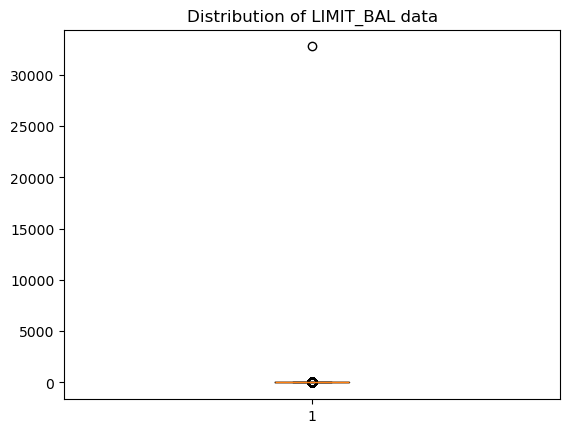

In [8]:
plt.boxplot(data["LIMIT_BAL"])
plt.title("Distribution of LIMIT_BAL data")
plt.show()

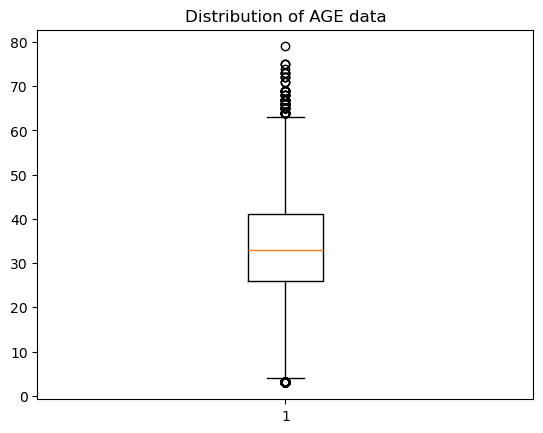

In [9]:
plt.boxplot(data["AGE"])
plt.title("Distribution of AGE data")
plt.show()

In [10]:
data.isnull().any()

ID                False
LIMIT_BAL         False
AGE               False
BILL_AMT1         False
BILL_AMT2         False
BILL_AMT3         False
BILL_AMT4         False
BILL_AMT5         False
BILL_AMT6         False
PAY_AMT1          False
PAY_AMT2          False
PAY_AMT3          False
PAY_AMT4          False
PAY_AMT5          False
PAY_AMT6          False
Default Status    False
dtype: bool

In [11]:
data["Default Status"].unique()

array(['Default', 'Not Default'], dtype=object)

In [12]:
data["Default Status"] = data["Default Status"].map({"Default":1,"Not Default":0}) # Encoding

In [13]:
data

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,30709.50416,29015.123424,28526.276559,2613.957537,689.000000,2584.508988,2250.186122,2300.375885,2608.76576,1
1,2,12.0,26,2682.0,1725.0,2682.0,3272.00000,3455.000000,3261.000000,2613.957537,1.000000,1.000000,1.000000,2300.375885,2.00000,1
2,3,9.0,34,29239.0,1427.0,13559.0,14331.00000,14948.000000,15549.000000,1518.000000,15.000000,1.000000,1.000000,1.000000,5.00000,0
3,4,5.0,37,4699.0,48233.0,49291.0,28314.00000,28959.000000,29547.000000,2.000000,219.000000,12.000000,11.000000,169.000000,1.00000,0
4,5,5.0,57,8617.0,567.0,35835.0,294.00000,19146.000000,19131.000000,2.000000,36681.000000,1.000000,9.000000,689.000000,679.00000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.00000,31237.000000,1598.000000,85.000000,2.000000,53.000000,347.000000,5.000000,1.00000,0
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.00000,519.000000,28526.276559,1837.000000,3526.000000,8998.000000,129.000000,2300.375885,2608.76576,0
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.00000,2582.000000,19357.000000,2613.957537,2922.761583,22.000000,42.000000,2.000000,31.00000,1
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.00000,11855.000000,48944.000000,859.000000,349.000000,1178.000000,1926.000000,52964.000000,184.00000,1


# Part-2: Working with Models 

### Devide data in target and feature variable into train test split

In [14]:
x = data.drop("Default Status",axis=1)
y = data["Default Status"]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

### Model Build and train

In [17]:
from sklearn.naive_bayes import GaussianNB

In [18]:
model = GaussianNB()

In [19]:
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [20]:
model.score(x_train,y_train)

0.7503333333333333

In [21]:
model.score(x_test,y_test)

0.7511666666666666

### Model Evalution

In [22]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score

In [23]:
ypri = model.predict(x_test)
ypri

array([0, 0, 0, ..., 0, 0, 1])

In [24]:
accuracy_score(y_test,ypri)

0.7511666666666666

In [25]:
precision_score(y_test,ypri)

0.16666666666666666

In [26]:
recall_score(y_test,ypri)

0.03427265803503427

In [27]:
c = confusion_matrix(y_test,ypri)
c

array([[4462,  225],
       [1268,   45]])

<Axes: >

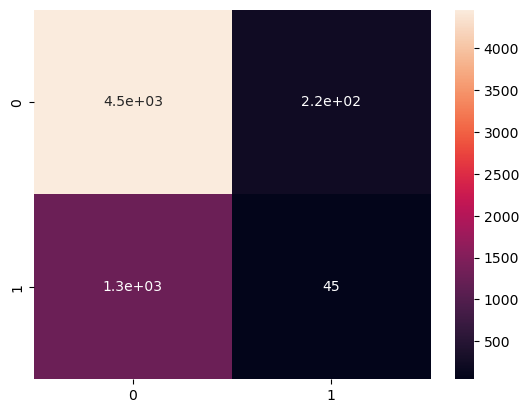

In [28]:
sns.heatmap(c,annot=True)

In [29]:
print(classification_report(y_test,ypri))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86      4687
           1       0.17      0.03      0.06      1313

    accuracy                           0.75      6000
   macro avg       0.47      0.49      0.46      6000
weighted avg       0.64      0.75      0.68      6000

